
--- Evaluating Fold 2 ---
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 0.9999
Confusion Matrix:
[[29797    20]
 [    3 26080]]

--- Evaluating Fold 3 ---
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 0.9999
Confusion Matrix:
[[29797    20]
 [    3 26080]]

--- Evaluating Fold 4 ---
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 0.9999
Confusion Matrix:
[[29797    20]
 [    3 26080]]

--- Evaluating Fold 5 ---
Acc: 0.9978, Prec: 0.9992, Rec: 0.9961, F1: 0.9976, AUC: 0.9999
Confusion Matrix:
[[29797    20]
 [  103 25980]]

EXTERNAL VALIDATION RESULTS (Average over folds)
Avg Accuracy:  0.9991
Avg Precision: 0.9992
Avg Recall:    0.9989
Avg F1-Score:  0.9991
Avg AUC:       0.9999

Global AUC (all predictions): 0.9999


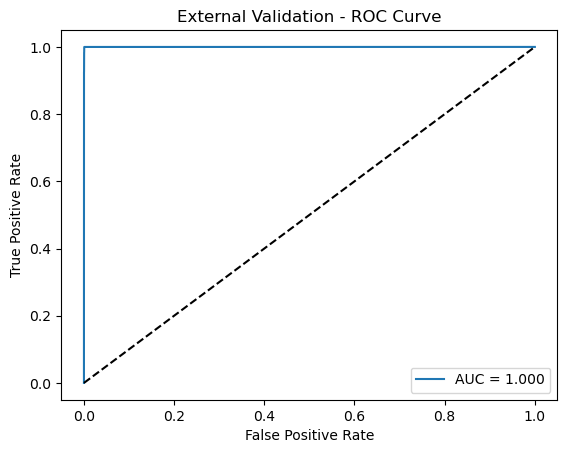

In [18]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import dlib
from scipy.spatial import distance as dist

# ------------------------------
# 1. Device & Dependencies
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# EAR detector (same as before)
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("C:/Users/DELL/Desktop/External Validation/shape_predictor_68_face_landmarks.dat")  # <-- update this path

# ------------------------------
# 2. Model Definition (must match your training)
# ------------------------------
class ResidualBlock(torch.nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(in_ch, in_ch, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(in_ch)
        self.conv2 = torch.nn.Conv2d(in_ch, in_ch, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(in_ch)

    def forward(self, x):
        identity = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return torch.relu(out)

class ImprovedCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, 3, padding=1),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.res = ResidualBlock(32)
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 8 * 8, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.res(x)
        x = self.layer3(x)
        x = self.fc(x)
        return x

# ------------------------------
# 3. Dataset Class (test transform only)
# ------------------------------
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class EyeDatasetExternal(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        for label, cls in enumerate(["open", "closed"]):
            path = os.path.join(root_dir, cls)
            for img in os.listdir(path):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(path, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = cv2.equalizeHist(img)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ------------------------------
# 4. EAR Functions (copy from your code)
# ------------------------------
def ear_calc(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def compute_ear(img_pil):
    img_np = np.array(img_pil)
    faces = detector(img_np, 0)
    if len(faces) == 0:
        return None
    shape = predictor(img_np, faces[0])
    pts = np.array([[p.x, p.y] for p in shape.parts()])
    left = ear_calc(pts[42:48])
    right = ear_calc(pts[36:42])
    return (left + right) / 2.0

# ------------------------------
# 5. Evaluate a single model on external dataset
# ------------------------------
def evaluate_model(model_path, external_dataset_root, thresholds=(0.2, 0.3)):
    """
    Load a saved model and evaluate on the external dataset.
    thresholds: (LOW, HIGH) for EAR adjustment. You can compute them from the
                training set (as you did) or use fixed values if you prefer.
    Returns: y_true, y_pred, y_score (list of probabilities)
    """
    # Load model
    model = ImprovedCNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Create dataset and loader
    dataset = EyeDatasetExternal(external_dataset_root, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    y_true, y_pred, y_score = [], [], []
    LOW, HIGH = thresholds

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)  # shape [batch, 2]

            for i in range(len(x)):
                base_logit = logits[i][1].item()  # logit for "closed" class

                # Reconstruct PIL image for EAR
                img_tensor = x[i].cpu()
                img_np = ((img_tensor.numpy().squeeze() * 0.5 + 0.5) * 255).astype(np.uint8)
                img_pil = Image.fromarray(img_np)

                ear = compute_ear(img_pil)
                if ear is not None:
                    if ear < LOW:
                        ear_adj = 1.5
                    elif ear > HIGH:
                        ear_adj = -1.5
                    else:
                        ear_adj = 0.0
                else:
                    ear_adj = 0.0

                fused_logit = base_logit + ear_adj
                final_prob = 1 / (1 + np.exp(-fused_logit))
                pred = 1 if final_prob > 0.5 else 0

                y_true.append(y[i].item())
                y_pred.append(pred)
                y_score.append(final_prob)

    return y_true, y_pred, y_score

# ------------------------------
# 6. Run external validation for all folds
# ------------------------------
external_root = "D:/Real_Dataset/Real_Dataset"   # <-- SET YOUR PATH HERE
models_dir = "C:/Users/DELL/Desktop/m"                     # where fold models are stored

# Thresholds – ideally you should compute them on the training set.
# If you didn't save them, you can use your earlier computed values or fixed ones.
# For this example we use fixed values (common for EAR).
LOW, HIGH = 0.2, 0.3

all_true = []
all_score = []
fold_metrics = []

for fold in range(1, 6):
    model_path = os.path.join(models_dir, f"model_fold_{fold}.pth")
    if not os.path.exists(model_path):
        print(f"Warning: {model_path} not found. Skipping.")
        continue

    print(f"\n--- Evaluating Fold {fold} ---")
    y_true, y_pred, y_score = evaluate_model(model_path, external_root, thresholds=(LOW, HIGH))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, y_score)

    fold_metrics.append((acc, prec, rec, f1, auc))
    print(f"Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

    # Optionally, show confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Accumulate for global ROC
    all_true.extend(y_true)
    all_score.extend(y_score)

# ------------------------------
# 7. Overall performance (across all folds)
# ------------------------------
if fold_metrics:
    print("\n" + "="*50)
    print("EXTERNAL VALIDATION RESULTS (Average over folds)")
    print("="*50)
    avg_acc = np.mean([m[0] for m in fold_metrics])
    avg_prec = np.mean([m[1] for m in fold_metrics])
    avg_rec = np.mean([m[2] for m in fold_metrics])
    avg_f1 = np.mean([m[3] for m in fold_metrics])
    avg_auc = np.mean([m[4] for m in fold_metrics])
    print(f"Avg Accuracy:  {avg_acc:.4f}")
    print(f"Avg Precision: {avg_prec:.4f}")
    print(f"Avg Recall:    {avg_rec:.4f}")
    print(f"Avg F1-Score:  {avg_f1:.4f}")
    print(f"Avg AUC:       {avg_auc:.4f}")

    # Global ROC (combining all predictions)
    if all_true:
        global_auc = roc_auc_score(all_true, all_score)
        print(f"\nGlobal AUC (all predictions): {global_auc:.4f}")

        # Optional: plot ROC
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(all_true, all_score)
        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {global_auc:.3f}')
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('External Validation - ROC Curve')
        plt.legend()
        plt.show()